# Model Building & Evaluation

## Problem Statement

Build machine learning models to predict Clean Alternative Fuel Vehicle (CAFV) eligibility based on vehicle attributes.

## Objectives

1. Prepare the modeling dataset.
2. Build a baseline Logistic Regression model.
3. Build an advanced Random Forest classifier.
4. Perform hyperparameter tuning.
5. Evaluate models using:
   - Accuracy
   - Macro F1-score
   - Weighted F1-score
   - Classification Report
   - Confusion Matrix
6. Analyze feature importance.
7. Compare model performance and identify the best-performing model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("ev_model_ready_dataset.csv")

print("Dataset Loaded Successfully")

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
df.info()

Saving ev_model_ready_dataset.csv to ev_model_ready_dataset.csv


/tmp/ipykernel_3434/1524475706.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ev_model_ready_dataset.csv")


Dataset Loaded Successfully
Rows    : 270,262
Columns : 27
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270262 entries, 0 to 270261
Data columns (total 27 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   VIN_1-10                                         270262 non-null  object 
 1   County                                           270262 non-null  int64  
 2   City                                             270262 non-null  int64  
 3   State                                            270262 non-null  int64  
 4   Postal_Code                                      270262 non-null  float64
 5   Model_Year                                       270262 non-null  int64  
 6   Make                                             270262 non-null  int64  
 7   Model                                            270262 non-null  int64  
 8   Electric_Vehicle_Type              

In [ ]:
df["CAFV_Status"].value_counts()

,count
CAFV_Status,
2,169872
0,76360
1,24030


## Target Variable

The `CAFV_Status` feature represents the processed CAFV eligibility status.

- 0 = Eligible
- 1 = Not Eligible
- 2 = Unknown

Records with an Unknown status are excluded from supervised binary classification because their eligibility outcome is not available.

In [ ]:
df_ml = df[df["CAFV_Status"] != 2].copy()

print("Modeling Dataset Shape:", df_ml.shape)
print("\nTarget Distribution:")
print(df_ml["CAFV_Status"].value_counts())

Modeling Dataset Shape: (100390, 27)

Target Distribution:
CAFV_Status
0    76360
1    24030
Name: count, dtype: int64


In [ ]:
selected_features = [
    "County",
    "City",
    "Make",
    "Model",
    "Electric_Vehicle_Type",
    "Electric_Range",
    "Longitude",
    "Latitude",
    "Vehicle_Age",
    "Vehicle_Vintage",
    "Premium_Brand",
    "Is_BEV"
]

X = df_ml[selected_features].copy()
y = df_ml["CAFV_Status"].copy()

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (100390, 12)
Target Shape: (100390,)


In [ ]:
print(X.columns.tolist())

['County', 'City', 'Make', 'Model', 'Electric_Vehicle_Type', 'Electric_Range', 'Longitude', 'Latitude', 'Vehicle_Age', 'Vehicle_Vintage', 'Premium_Brand', 'Is_BEV']


In [ ]:
print(X.isnull().sum())

County                   0
City                     0
Make                     0
Model                    0
Electric_Vehicle_Type    0
Electric_Range           0
Longitude                0
Latitude                 0
Vehicle_Age              0
Vehicle_Vintage          0
Premium_Brand            0
Is_BEV                   0
dtype: int64


In [ ]:
print(y.value_counts())

CAFV_Status
0    76360
1    24030
Name: count, dtype: int64


## Train-Test Split

The dataset is divided into training and testing subsets.

An 80:20 split is used, with stratification to preserve the proportion of Eligible and Not Eligible vehicles in both datasets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)
print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Feature Shape : (80312, 12)
Testing Feature Shape  : (20078, 12)
Training Target Shape  : (80312,)
Testing Target Shape   : (20078,)


In [ ]:
print("Training Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Target Distribution:
CAFV_Status
0    61088
1    19224
Name: count, dtype: int64

Testing Target Distribution:
CAFV_Status
0    15272
1     4806
Name: count, dtype: int64


## Feature Scaling

StandardScaler is applied to the training and testing features for Logistic Regression.

The scaler is fitted only on the training data to prevent information from the test set from influencing the model.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape :", X_test_scaled.shape)

Scaled Training Shape: (80312, 12)
Scaled Testing Shape : (20078, 12)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_macro_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="macro"
)

lr_weighted_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)


print("LOGISTIC REGRESSION PERFORMANCE")


print(f"Accuracy          : {lr_accuracy:.4f}")
print(f"Macro F1 Score    : {lr_macro_f1:.4f}")
print(f"Weighted F1 Score : {lr_weighted_f1:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy          : 0.9987
Macro F1 Score    : 0.9982
Weighted F1 Score : 0.9987


In [ ]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Eligible", "Not Eligible"]
))

              precision    recall  f1-score   support

    Eligible       1.00      1.00      1.00     15272
Not Eligible       1.00      1.00      1.00      4806

    accuracy                           1.00     20078
   macro avg       1.00      1.00      1.00     20078
weighted avg       1.00      1.00      1.00     20078



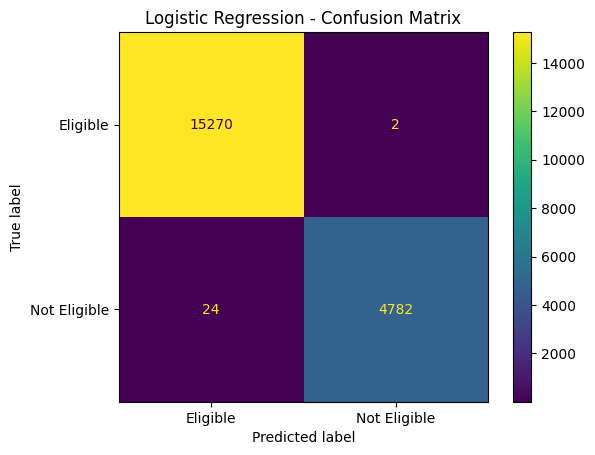

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Eligible", "Not Eligible"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Random Forest — Advanced Model

Random Forest is used as the advanced classification model.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions between vehicle characteristics without requiring feature scaling.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_macro_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)

rf_weighted_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)


print("RANDOM FOREST PERFORMANCE")


print(f"Accuracy          : {rf_accuracy:.4f}")
print(f"Macro F1 Score    : {rf_macro_f1:.4f}")
print(f"Weighted F1 Score : {rf_weighted_f1:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy          : 1.0000
Macro F1 Score    : 1.0000
Weighted F1 Score : 1.0000


In [ ]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Eligible", "Not Eligible"]
))

              precision    recall  f1-score   support

    Eligible       1.00      1.00      1.00     15272
Not Eligible       1.00      1.00      1.00      4806

    accuracy                           1.00     20078
   macro avg       1.00      1.00      1.00     20078
weighted avg       1.00      1.00      1.00     20078



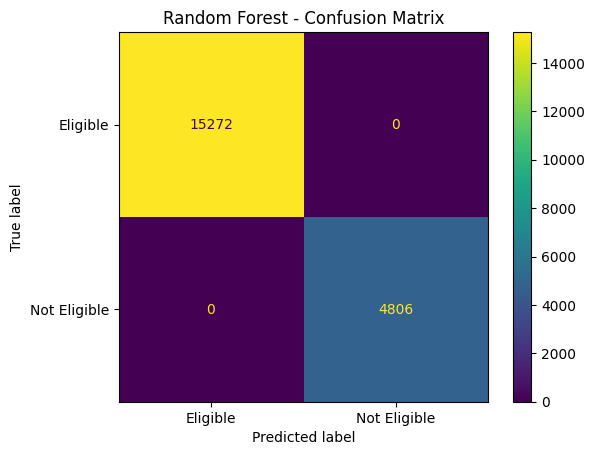

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Eligible", "Not Eligible"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

## Hyperparameter Tuning — Random Forest

GridSearchCV is used to identify a suitable combination of Random Forest hyperparameters.

Three-fold cross-validation is used with weighted F1-score as the optimization metric.

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1_weighted', verbose=1)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated Weighted F1:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validated Weighted F1:
1.0


In [ ]:
best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
+)

best_rf.fit(X_train, y_train)

y_pred_best_rf = best_rf.predict(X_test)

In [ ]:
best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)

best_rf_macro_f1 = f1_score(
    y_test,
    y_pred_best_rf,
    average="macro"
)

best_rf_weighted_f1 = f1_score(
    y_test,
    y_pred_best_rf,
    average="weighted"
)


print("TUNED RANDOM FOREST PERFORMANCE")


print(f"Accuracy          : {best_rf_accuracy:.4f}")
print(f"Macro F1 Score    : {best_rf_macro_f1:.4f}")
print(f"Weighted F1 Score : {best_rf_weighted_f1:.4f}")

TUNED RANDOM FOREST PERFORMANCE
Accuracy          : 1.0000
Macro F1 Score    : 1.0000
Weighted F1 Score : 1.0000


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,Electric_Range,0.681093
3,Model,0.074984
11,Is_BEV,0.064821
2,Make,0.063451
4,Electric_Vehicle_Type,0.058635
8,Vehicle_Age,0.027737
10,Premium_Brand,0.013718
9,Vehicle_Vintage,0.013534
7,Latitude,0.001163
1,City,0.000373


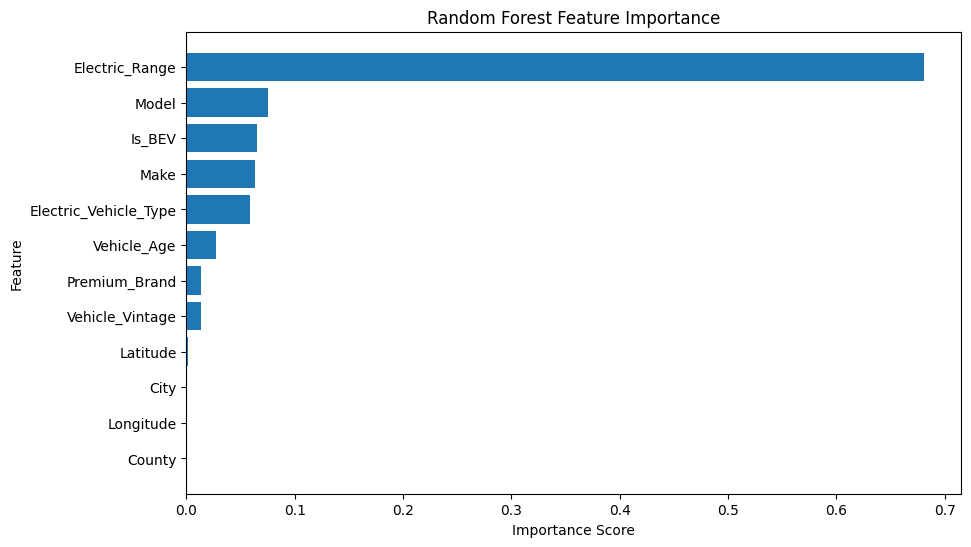

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## Feature Importance Analysis

The Random Forest feature importance analysis shows that Electric Range is the dominant predictor of CAFV eligibility, with an importance score of 0.6811.

Vehicle Model, Is_BEV, Make, and Electric Vehicle Type are the next most influential features, indicating that vehicle-specific characteristics also contribute significantly to the prediction.

Vehicle Age, Premium Brand, and Vehicle Vintage have relatively smaller contributions.

Geographical features such as Latitude, City, Longitude, and County have very low importance compared with vehicle-related attributes.

Overall, the results indicate that CAFV eligibility prediction is primarily driven by electric range and vehicle characteristics rather than geographic location.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        best_rf_accuracy
    ],
    "Macro F1": [
        lr_macro_f1,
        rf_macro_f1,
        best_rf_macro_f1
    ],
    "Weighted F1": [
        lr_weighted_f1,
        rf_weighted_f1,
        best_rf_weighted_f1
    ]
})

model_comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.998705,0.998219,0.998704
1,Random Forest,1.000000,1.000000,1.000000
2,Tuned Random Forest,1.000000,1.000000,1.000000


## Model Comparison

Logistic Regression achieved an accuracy of 99.87% and a weighted F1-score of 99.87%, providing a strong baseline.

The Random Forest model achieved 100% accuracy, macro F1-score, and weighted F1-score on the test set.

Hyperparameter tuning produced a Random Forest model with the same test-set performance. Therefore, tuning did not produce a measurable improvement over the original Random Forest, but confirmed that the selected parameter configuration performs strongly under cross-validation.

Based on predictive performance and its ability to provide feature importance, the tuned Random Forest was selected as the final model.

##Random Forest Without Electric Range

In [ ]:
# Create a feature set without Electric Range
features_without_range = [
    feature for feature in selected_features
    if feature != "Electric_Range"
]

X_no_range = df_ml[features_without_range].copy()

print("Features without Electric Range:")
print(features_without_range)

print("\nShape:", X_no_range.shape)

Features without Electric Range:
['County', 'City', 'Make', 'Model', 'Electric_Vehicle_Type', 'Longitude', 'Latitude', 'Vehicle_Age', 'Vehicle_Vintage', 'Premium_Brand', 'Is_BEV']

Shape: (100390, 11)


In [ ]:
X_no_range_train, X_no_range_test, y_no_range_train, y_no_range_test = train_test_split(
    X_no_range,
    y,
    test_size=0.20,dfkn
    random_state=42,
    stratify=y
)

print("Training Shape:", X_no_range_train.shape)
print("Testing Shape :", X_no_range_test.shape)

Training Shape: (80312, 11)
Testing Shape : (20078, 11)


In [ ]:
rf_no_range = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_no_range.fit(
    X_no_range_train,
    y_no_range_train
)

y_pred_no_range = rf_no_range.predict(X_no_range_test)

In [ ]:
no_range_accuracy = accuracy_score(
    y_no_range_test,
    y_pred_no_range
)

no_range_macro_f1 = f1_score(
    y_no_range_test,
    y_pred_no_range,
    average="macro"
)

no_range_weighted_f1 = f1_score(
    y_no_range_test,
    y_pred_no_range,
    average="weighted"
)


print("RANDOM FOREST WITHOUT ELECTRIC RANGE")


print(f"Accuracy          : {no_range_accuracy:.4f}")
print(f"Macro F1 Score    : {no_range_macro_f1:.4f}")
print(f"Weighted F1 Score : {no_range_weighted_f1:.4f}")

RANDOM FOREST WITHOUT ELECTRIC RANGE
Accuracy          : 0.9962
Macro F1 Score    : 0.9948
Weighted F1 Score : 0.9962


###Effect of Electric Range

To assess the influence of Electric Range on CAFV eligibility prediction, a separate Random Forest model was trained after removing the Electric_Range feature.

The original Random Forest achieved 100% accuracy, while the model without Electric Range achieved 99.62% accuracy.

The reduction in performance demonstrates that Electric Range contributes substantially to the prediction of CAFV eligibility.

This finding is consistent with the feature importance analysis, where Electric Range had the highest importance score of 0.6811.

Therefore, Electric Range is the strongest predictive feature among the selected vehicle attributes.

In [ ]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Random Forest (Without Electric Range)"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        best_rf_accuracy,
        no_range_accuracy
    ],
    "Macro F1": [
        lr_macro_f1,
        rf_macro_f1,
        best_rf_macro_f1,
        no_range_macro_f1
    ],
    "Weighted F1": [
        lr_weighted_f1,
        rf_weighted_f1,
        best_rf_weighted_f1,
        no_range_weighted_f1
    ]
})

final_model_comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.998705,0.998219,0.998704
1,Random Forest,1.000000,1.000000,1.000000
2,Tuned Random Forest,1.000000,1.000000,1.000000
3,Random Forest (Without Electric Range),0.996215,0.994801,0.996214


In [ ]:
import joblib

joblib.dump(rf_model, "cafv_random_forest.pkl")

['cafv_random_forest.pkl']

In [ ]:
feature_columns = [
    'County',
    'City',
    'Make',
    'Model',
    'Electric_Vehicle_Type',
    'Electric_Range',
    'Longitude',
    'Latitude',
    'Vehicle_Age',
    'Vehicle_Vintage',
    'Premium_Brand',
    'Is_BEV'
]

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

#Conclusion

The machine learning models were developed to predict CAFV eligibility using vehicle-related attributes.

Logistic Regression was established as the baseline model and achieved an accuracy of 99.87%, with a macro F1-score of 99.82% and weighted F1-score of 99.87%.

Random Forest achieved 100% accuracy, macro F1-score, and weighted F1-score on the test dataset. Hyperparameter tuning using GridSearchCV confirmed the strong performance of the model, with a best cross-validated weighted F1-score of 1.00.

Feature importance analysis showed that Electric Range was the dominant predictive feature, with an importance score of 0.6811. Model, Is_BEV, Make, and Electric Vehicle Type were the next most influential features.

A sensitivity analysis was performed by removing Electric Range from the Random Forest model. Performance decreased from 100% accuracy to 99.62%, further demonstrating the strong predictive contribution of Electric Range.

Based on the evaluation results, the Tuned Random Forest was selected as the final model for CAFV eligibility prediction.